In [314]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, date
import plotly.graph_objects as go
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import calendar
import math
from typing import Optional, List, Dict, Tuple, Literal
from datetime import datetime
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.fft import fft, fftfreq
from scipy.stats import linregress
from scipy.stats import pearsonr
import json
import os
import re
import sys
import july
import july.utils as july_utils
from plotly_calheatmap import calheatmap
from glob import glob
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
pd.options.display.max_columns = None

In [3]:
def calendar_plot_binary(
    dates,
    data,
    cmap=None,
    title=None,
    figsize=(12, 8),
    ncols=3,
    value_label=False,
    date_label=True,
    month_label=True,
    weeknum_label=False,
):
    """
    Calendar heatmap for binary activity data.

    Parameters
    ----------
    dates : array-like
        Dates corresponding to each activity value.

    data : array-like
        Binary values:
            0 = no activity
            1 = activity

    cmap : matplotlib colormap, optional
        Colormap containing exactly two colours.
        Default:
            0 -> very light grey
            1 -> blue

    title : str, optional
        Overall figure title.

    figsize : tuple
        Figure size.

    ncols : int
        Number of calendar months per row.

    value_label : bool
        Display the activity value inside each day cell.

    date_label : bool
        Display day numbers.

    month_label : bool
        Display month names.

    weeknum_label : bool
        Display week numbers.

    Returns
    -------
    matplotlib.axes.Axes
    """

    # ---------------------------------------------------------
    # Prepare data
    # ---------------------------------------------------------

    df = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "value": np.asarray(data)
    })

    df["value"] = df["value"].astype(int)

    # Make sure data is binary
    if not df["value"].isin([0, 1]).all():
        raise ValueError("calendar_plot_binary expects activity values of only 0 and 1.")

    # If duplicate dates exist, keep the maximum activity.
    # Therefore, if anything happened on a day -> activity = 1.
    df = (
        df.groupby("date", as_index=False)["value"]
        .max()
    )

    activity = dict(
        zip(
            df["date"].dt.normalize(),
            df["value"]
        )
    )

    # ---------------------------------------------------------
    # Default binary colour map
    # ---------------------------------------------------------

    if cmap is None:
        cmap = ListedColormap([
            "#eeeeee",   # 0 = no activity
            "#2166ac",   # 1 = activity
        ])

    # Require two colours
    if cmap.N < 2:
        raise ValueError("cmap must contain at least two colours.")

    # ---------------------------------------------------------
    # Determine months to display
    # ---------------------------------------------------------

    min_date = df["date"].min()
    max_date = df["date"].max()

    months = pd.period_range(
        min_date.to_period("M"),
        max_date.to_period("M"),
        freq="M"
    )

    nmonths = len(months)
    nrows = math.ceil(nmonths / ncols)

    # ---------------------------------------------------------
    # Figure
    # ---------------------------------------------------------

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False
    )

    axes = axes.flatten()

    # ---------------------------------------------------------
    # Calendar settings
    # ---------------------------------------------------------

    # Monday = 0 ... Sunday = 6
    calendar.setfirstweekday(calendar.MONDAY)

    weekday_names = [
        "Mon", "Tue", "Wed", "Thu",
        "Fri", "Sat", "Sun"
    ]

    # ---------------------------------------------------------
    # Draw each month
    # ---------------------------------------------------------

    for ax_idx, period in enumerate(months):

        ax = axes[ax_idx]

        year = period.year
        month = period.month

        cal = calendar.monthcalendar(year, month)

        nweeks = len(cal)

        # Calendar background
        ax.set_xlim(0, 7)
        ax.set_ylim(nweeks, 0)

        # -----------------------------------------------------
        # Month title
        # -----------------------------------------------------

        if month_label:
            month_name = period.strftime("%B %Y")

            ax.set_title(
                month_name,
                fontsize=11,
                fontweight="bold",
                pad=12
            )

        # -----------------------------------------------------
        # Weekday labels
        # -----------------------------------------------------

        ax.set_xticks(
            np.arange(7) + 0.5
        )

        ax.set_xticklabels(
            weekday_names,
            fontsize=8
        )

        ax.tick_params(
            axis="x",
            bottom=False,
            top=False,
            length=0
        )

        # Remove y axis
        ax.set_yticks([])

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        # -----------------------------------------------------
        # Draw days
        # -----------------------------------------------------

        for week_idx, week in enumerate(cal):

            for weekday_idx, day in enumerate(week):

                # Empty cell before/after month
                if day == 0:
                    continue

                date = pd.Timestamp(
                    year=year,
                    month=month,
                    day=day
                )

                value = activity.get(
                    date.normalize(),
                    0
                )

                # -------------------------------------------------
                # FIXED COLOUR MAPPING
                #
                # This is the important part.
                #
                # 0 ALWAYS gets cmap[0]
                # 1 ALWAYS gets cmap[1]
                #
                # There is no per-month normalization.
                # -------------------------------------------------

                cell_color = cmap(value)

                rect = Rectangle(
                    (
                        weekday_idx,
                        week_idx
                    ),
                    1,
                    1,
                    facecolor=cell_color,
                    edgecolor="white",
                    linewidth=1.5
                )

                ax.add_patch(rect)

                # -------------------------------------------------
                # Day number
                # -------------------------------------------------

                if date_label:

                    # Choose text colour based on activity
                    text_color = (
                        "white"
                        if value == 1
                        else "#555555"
                    )

                    ax.text(
                        weekday_idx + 0.5,
                        week_idx + 0.5,
                        str(day),
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=text_color
                    )

                # -------------------------------------------------
                # Activity value
                # -------------------------------------------------

                if value_label:

                    ax.text(
                        weekday_idx + 0.5,
                        week_idx + 0.78,
                        str(value),
                        ha="center",
                        va="center",
                        fontsize=6,
                        color="white" if value == 1 else "#777777"
                    )

        # -----------------------------------------------------
        # Optional week numbers
        # -----------------------------------------------------

        if weeknum_label:

            for week_idx, week in enumerate(cal):

                valid_days = [
                    d for d in week if d != 0
                ]

                if valid_days:

                    first_day = pd.Timestamp(
                        year=year,
                        month=month,
                        day=valid_days[0]
                    )

                    week_number = first_day.isocalendar().week

                    ax.text(
                        -0.18,
                        week_idx + 0.5,
                        str(week_number),
                        ha="right",
                        va="center",
                        fontsize=7,
                        color="#777777"
                    )

        # -----------------------------------------------------
        # Grid boundaries
        # -----------------------------------------------------

        ax.set_xlim(0, 7)
        ax.set_ylim(nweeks, 0)

    # ---------------------------------------------------------
    # Hide unused axes
    # ---------------------------------------------------------

    for i in range(nmonths, len(axes)):
        axes[i].set_visible(False)

    # ---------------------------------------------------------
    # Figure title
    # ---------------------------------------------------------

    if title is not None:

        fig.suptitle(
            title,
            fontsize=14,
            fontweight="bold",
            y=1.02
        )

    plt.tight_layout()

    return axes

In [4]:
con = duckdb.connect(
    database = "../data/MIG_Cement_Records.db",
    read_only = True
)

In [5]:
query = """

        SELECT
            table_schema, table_name
        FROM
            information_schema.tables
        ORDER BY
            table_schema, table_name;

"""

result = con.execute(query).df()

In [6]:
result

,table_schema,table_name
0,main,CementTypes
1,main,Operations
2,main,Sites


In [7]:
def table_schema(table_name: str) -> None:
    query = f"""
    
                SELECT
                    column_name,
                    data_type
                FROM
                    information_schema.columns
                WHERE
                    table_name == '{table_name}'
    """

    result = con.execute(query).df()

    display(result)

In [8]:
table_schema("CementTypes")

,column_name,data_type
0,cement_type,VARCHAR


In [9]:
table_schema("Operations")

,column_name,data_type
0,date,VARCHAR
1,site_id,VARCHAR
2,cement_type,VARCHAR
3,planned_pour_tonnes,DOUBLE
4,consumed_tonnes,DOUBLE
5,opening_inventory_tonnes,DOUBLE
6,deliveries_tonnes,DOUBLE
7,closing_inventory_tonnes,DOUBLE
8,rain_mm,DOUBLE
9,avg_temp_c,DOUBLE


In [10]:
table_schema("Sites")

,column_name,data_type
0,site_id,VARCHAR
1,region,VARCHAR
2,silo_capacity,BIGINT
3,behavior,VARCHAR


In [11]:
con.execute(" SELECT COUNT(1) FROM Operations LIMIT 1 ").fetchone()

(32880,)

In [12]:
con.execute(" SELECT * FROM Operations LIMIT 5 ").df()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448


In [13]:
OPERATION_START_DATE = con.execute(" SELECT MIN(date::DATE) FROM Operations; ").fetchone()[0]
OPERATION_END_DATE = con.execute(" SELECT MAX(date::DATE) FROM Operations; ").fetchone()[0]

In [14]:
con.execute(" SELECT * FROM CementTypes").df()

,cement_type
0,CEM_I
1,CEM_II
2,CEM_III


In [15]:
con.execute(" SELECT DISTINCT(cement_type) FROM Operations;").fetchall()

[('CEM_III',), ('CEM_II',), ('CEM_I',)]

In [16]:
con.execute("SELECT * FROM Sites LIMIT 5;").df()

,site_id,region,silo_capacity,behavior
0,SITE_001,North,448,aggressive
1,SITE_002,South,288,conservative
2,SITE_003,East,314,aggressive
3,SITE_004,South,472,conservative
4,SITE_005,South,230,aggressive


In [17]:
con.execute("SELECT COUNT(site_id) FROM Sites;").fetchone()

(30,)

In [18]:
con.execute("SELECT COUNT(DISTINCT(site_id)) FROM Sites;").fetchone()

(30,)

In [19]:
query = """

        SELECT
            site_id,
            COUNT(1) as ActivityVolume
        FROM
            Operations
        GROUP BY
            site_id
        ORDER BY
            ActivityVolume DESC;
"""

result = con.execute(query).df()

In [20]:
result.head()

,site_id,ActivityVolume
0,SITE_008,1096
1,SITE_017,1096
2,SITE_025,1096
3,SITE_029,1096
4,SITE_030,1096


In [21]:
result.ActivityVolume.unique()

array([1096])

In [22]:
query = """

        SELECT
            COUNT(1)
        FROM
            Operations
        WHERE
            ROUND(closing_inventory_tonnes - opening_inventory_tonnes - deliveries_tonnes + consumed_tonnes, 2) > 0.01;

"""

res = con.execute(query).fetchone()

In [23]:
res

(0,)

In [24]:
query = """
        SELECT
            cement_type,
            COUNT(1) frequency
        FROM
            Operations
        GROUP BY
            cement_type
        ORDER BY
            frequency DESC;
"""

res = con.execute(query).df()

In [25]:
res

,cement_type,frequency
0,CEM_II,11097
1,CEM_I,10913
2,CEM_III,10870


In [26]:
query = """
        SELECT
            site_id,
            cement_type,
            COUNT(1) frequency
        FROM
            Operations
        GROUP BY
            site_id, cement_type
        ORDER BY
            site_id ASC,
            cement_type ASC;
"""

res = con.execute(query).df()

In [27]:
res.head()

,site_id,cement_type,frequency
0,SITE_001,CEM_I,375
1,SITE_001,CEM_II,374
2,SITE_001,CEM_III,347
3,SITE_002,CEM_I,357
4,SITE_002,CEM_II,350


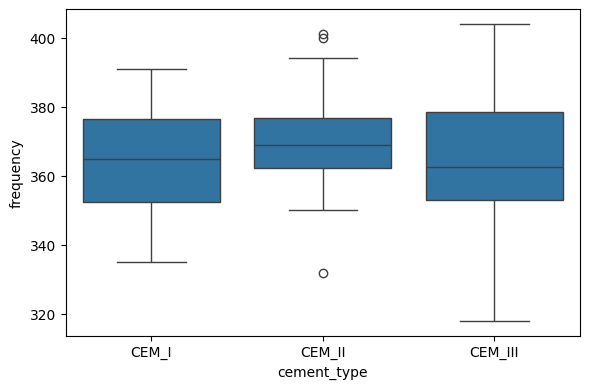

In [28]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.boxplot(data = res, x = "cement_type", y = "frequency", ax = ax)

plt.tight_layout()
plt.show()

In [29]:
con.execute(" SELECT * FROM Operations WHERE  opening_inventory_tonnes < 1; ").df()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-06,SITE_001,CEM_II,30.02,22.19,0.0,22.19,0.00,1.29,14.61,448
1,2022-01-07,SITE_001,CEM_I,33.60,33.60,0.0,47.72,14.12,0.90,4.48,448
2,2022-01-09,SITE_001,CEM_I,0.00,0.00,0.0,34.38,34.38,1.42,16.81,448
3,2022-01-16,SITE_001,CEM_II,37.74,37.74,0.0,42.69,4.95,3.90,0.21,448
4,2022-01-18,SITE_001,CEM_III,51.01,44.25,0.0,44.25,0.00,2.07,13.81,448
...,...,...,...,...,...,...,...,...,...,...,...
8144,2024-12-27,SITE_030,CEM_III,58.48,29.63,0.0,29.63,0.00,7.17,12.00,316
8145,2024-12-28,SITE_030,CEM_I,45.39,22.35,0.0,22.35,0.00,2.13,8.04,316
8146,2024-12-29,SITE_030,CEM_III,58.47,14.21,0.0,14.21,0.00,0.28,2.26,316
8147,2024-12-30,SITE_030,CEM_II,59.58,10.65,0.0,10.65,0.00,4.58,9.55,316


In [30]:
con.execute(" SELECT COUNT(1) FROM Operations WHERE (opening_inventory_tonnes + deliveries_tonnes - consumed_tonnes) < -0.01; ").fetchone()

(0,)

In [31]:
con.execute(" SELECT COUNT(1) FROM Operations WHERE planned_pour_tonnes < 1; ").fetchone()

(2993,)

In [32]:
con.execute(" SELECT * FROM Operations WHERE planned_pour_tonnes < 1 LIMIT 5; ").df()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-09,SITE_001,CEM_I,0.0,0.0,0.00,34.38,34.38,1.42,16.81,448
1,2022-02-13,SITE_001,CEM_II,0.0,0.0,0.00,47.34,47.34,14.89,11.62,448
2,2022-04-02,SITE_001,CEM_II,0.0,0.0,7.43,44.69,52.12,11.28,21.26,448
3,2022-04-03,SITE_001,CEM_III,0.0,0.0,52.12,22.88,75.00,2.19,15.64,448
4,2022-05-07,SITE_001,CEM_III,0.0,0.0,0.00,36.54,36.54,0.17,23.46,448


In [33]:
con.execute(" SELECT COUNT(1) FROM Operations WHERE planned_pour_tonnes < 1 and consumed_tonnes > 0; ").fetchone()

(0,)

In [34]:
def site_active_days(site_id: str, year: int) -> None:
    site_df = con.execute(f" SELECT date, SUM(planned_pour_tonnes) total_planned FROM Operations\
                          WHERE site_id == '{site_id}' AND year(date::DATE) == {year} GROUP BY date ORDER BY date ASC; ").df()

    site_df.date = pd.to_datetime(site_df.date)

    site_df.set_index("date", inplace = True)


    start = f"{year}-01-01"
    end = f"{year}-12-31"

    date_index = pd.date_range(start = start, end = end)

    site_df = pd.merge(
        pd.DataFrame(index = date_index),
        site_df,
        how = "left",
        left_index = True,
        right_index = True
    )

    site_df.index.name = "date"
    site_df.reset_index(inplace = True)

    site_df["activity"] = site_df.total_planned.astype(bool)

    calendar_plot_binary(
        site_df.date.values,
        site_df.activity.values,
        figsize = (12, 8),
        ncols = 3,
        title = f"Site Activity at {site_id} for year {year}"
    )

    plt.show()


In [81]:
con.execute(" SELECT * FROM Operations WHERE site_id == 'SITE_001' AND date == '2022-01-09'; ").df()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-09,SITE_001,CEM_I,0.0,0.0,0.0,34.38,34.38,1.42,16.81,448


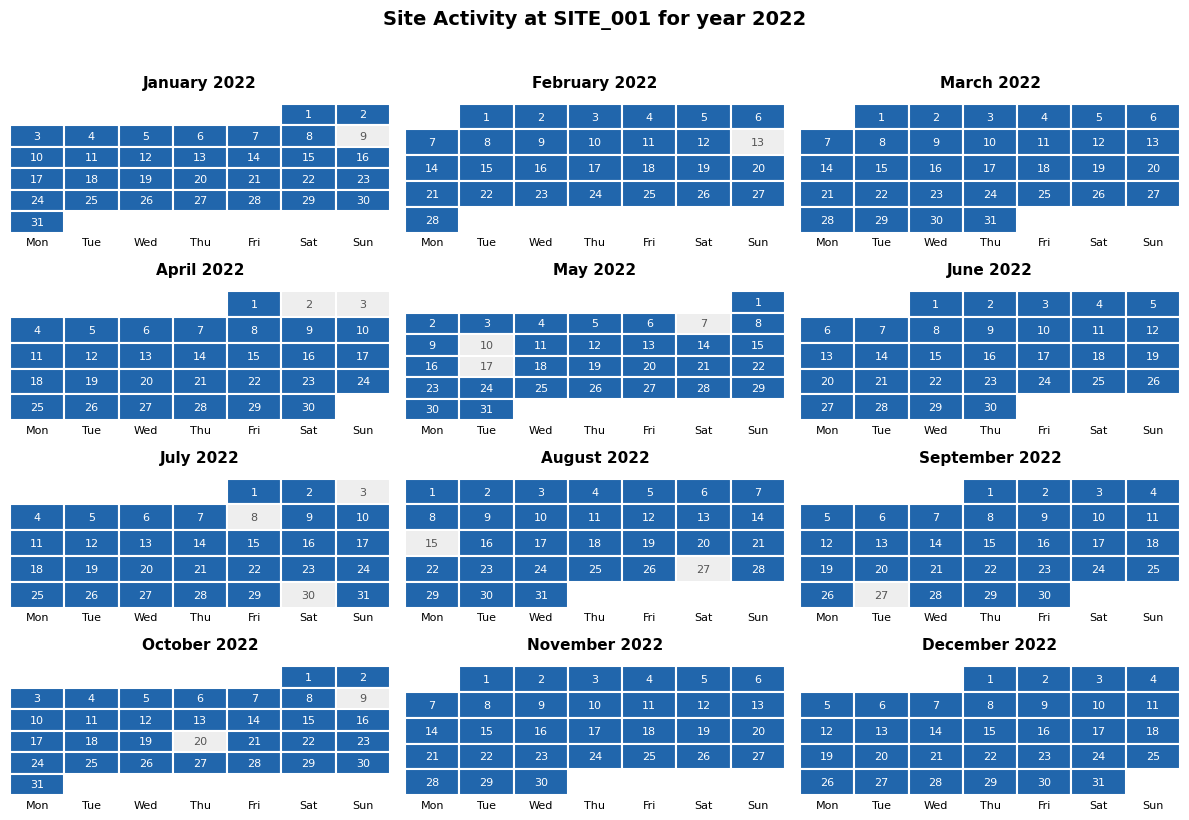

In [35]:
site_active_days("SITE_001", 2022)

In [36]:
query = """

    WITH no_activity_day as (
        SELECT
            date::DATE as date,
            site_id,
            SUM(planned_pour_tonnes) as total_planned_pour
        FROM
            Operations
        GROUP BY
            date, site_id
        HAVING
            total_planned_pour == 0
        ORDER BY
            date::DATE ASC
    )

    SELECT
        date,
        COUNT(1) as sites_off_count
    FROM
        no_activity_day
    GROUP BY
        date
    ORDER BY
        sites_off_count DESC
    LIMIT 10;
"""

con.execute(query).df()

,date,sites_off_count
0,2023-08-01,9
1,2023-12-20,8
2,2023-10-28,8
3,2024-01-09,7
4,2022-08-03,7
5,2023-09-04,7
6,2023-10-19,7
7,2024-12-31,7
8,2024-09-30,7
9,2024-11-02,7


In [37]:
(OPERATION_END_DATE - OPERATION_START_DATE).days

1095

In [74]:
sites = con.execute("SELECT site_id FROM sites").fetchall()
sites = [site[0] for site in sites]
sites[:5]

['SITE_001', 'SITE_002', 'SITE_003', 'SITE_004', 'SITE_005']

In [75]:
len(sites)

30

In [76]:
query = """

    SELECT
        DISTINCT(date::DATE) as date
    FROM
        Operations
    WHERE
        site_id == ?
    ORDER BY
        date::DATE ASC
"""

for site in sites:
    dates = con.execute(query, [site]).fetchall()
    if len(dates) < 1096:
        print(site, len(dates))

In [77]:
query = """

    PIVOT
        Operations
    ON
        site_id
    USING
        COUNT(*)
    GROUP BY
        date;
"""

pivot_df = con.execute(query).df()
pivot_df.set_index("date", inplace = True)
pivot_df.head()

,SITE_001,SITE_002,SITE_003,SITE_004,SITE_005,SITE_006,SITE_007,SITE_008,SITE_009,SITE_010,SITE_011,SITE_012,SITE_013,SITE_014,SITE_015,SITE_016,SITE_017,SITE_018,SITE_019,SITE_020,SITE_021,SITE_022,SITE_023,SITE_024,SITE_025,SITE_026,SITE_027,SITE_028,SITE_029,SITE_030
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-04-27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2023-01-01,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2023-07-09,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2023-08-13,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2023-11-17,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [78]:
record_per_day = {}
for site in pivot_df.columns.tolist():
    record_per_day[site] = pivot_df[site].unique().tolist()

In [79]:
record_per_day

{'SITE_001': [1],
 'SITE_002': [1],
 'SITE_003': [1],
 'SITE_004': [1],
 'SITE_005': [1],
 'SITE_006': [1],
 'SITE_007': [1],
 'SITE_008': [1],
 'SITE_009': [1],
 'SITE_010': [1],
 'SITE_011': [1],
 'SITE_012': [1],
 'SITE_013': [1],
 'SITE_014': [1],
 'SITE_015': [1],
 'SITE_016': [1],
 'SITE_017': [1],
 'SITE_018': [1],
 'SITE_019': [1],
 'SITE_020': [1],
 'SITE_021': [1],
 'SITE_022': [1],
 'SITE_023': [1],
 'SITE_024': [1],
 'SITE_025': [1],
 'SITE_026': [1],
 'SITE_027': [1],
 'SITE_028': [1],
 'SITE_029': [1],
 'SITE_030': [1]}

In [43]:
query = """

    SELECT
        date::DATE as date,
        (planned_pour_tonnes - consumed_tonnes) as delta
    FROM
        Operations
    WHERE 
        site_id == 'SITE_001' AND YEAR(date::DATE) == 2022
    ORDER BY
        date::DATE;
"""

delta_df = con.execute(query).df()

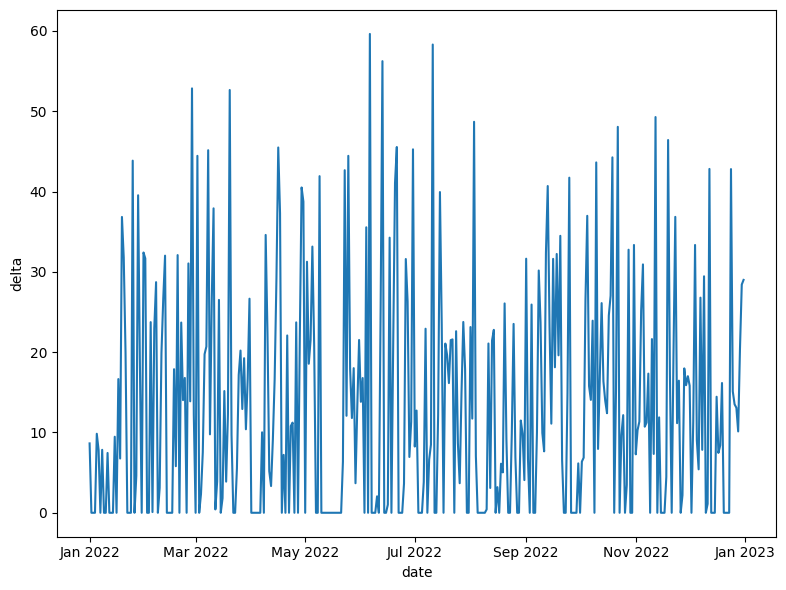

In [44]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(data = delta_df, x = "date", y = "delta", ax = ax)

ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [45]:
query = """

    SELECT
        date::DATE as date,
        rain_mm
    FROM
        Operations
    WHERE
        site_id == 'SITE_001' AND YEAR(date::DATE) == 2022
    ORDER BY
        date::DATE ASC;
"""


rain_df = con.execute(query).df()

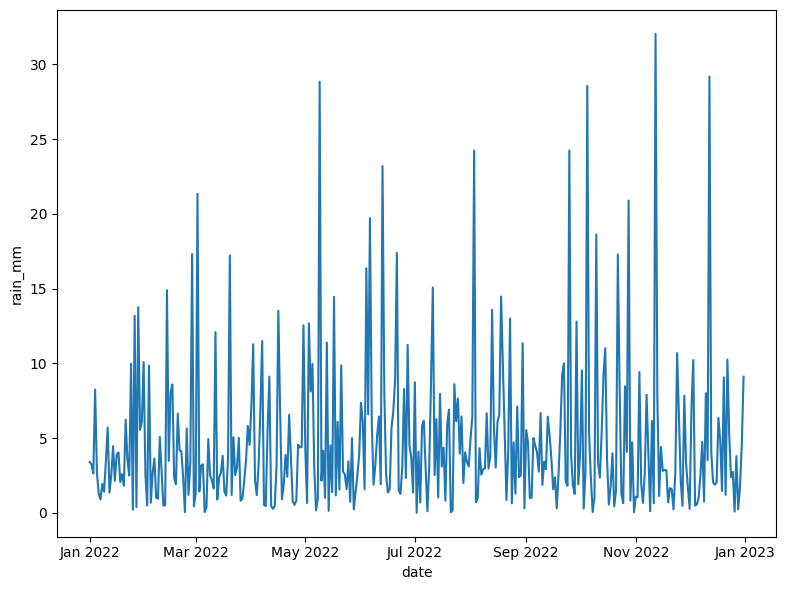

In [46]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(data = rain_df, x = "date", y = "rain_mm", ax = ax)

ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [47]:
query = """

    SELECT
        date::DATE as date,
        avg_temp_c
    FROM
        Operations
    WHERE
        site_id == 'SITE_001' AND YEAR(date::DATE) == 2022
    ORDER BY
        date::DATE ASC;
"""

temp_df = con.execute(query).df()

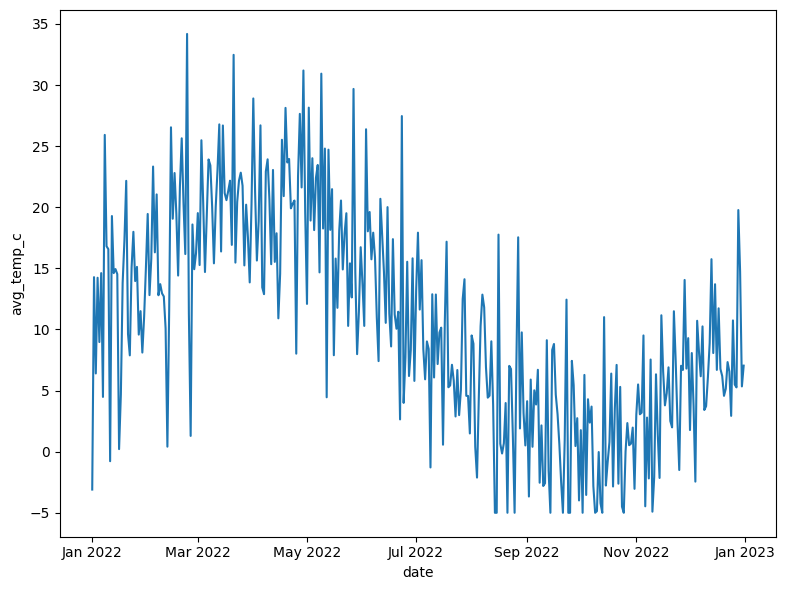

In [48]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(data = temp_df, x = "date", y = "avg_temp_c", ax = ax)

ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [49]:
query = """

    SELECT
        date::DATE as date,
        (planned_pour_tonnes - consumed_tonnes) as delta
    FROM
        Operations
    ORDER BY
        date::DATE;
"""

delta_df = con.execute(query).df()

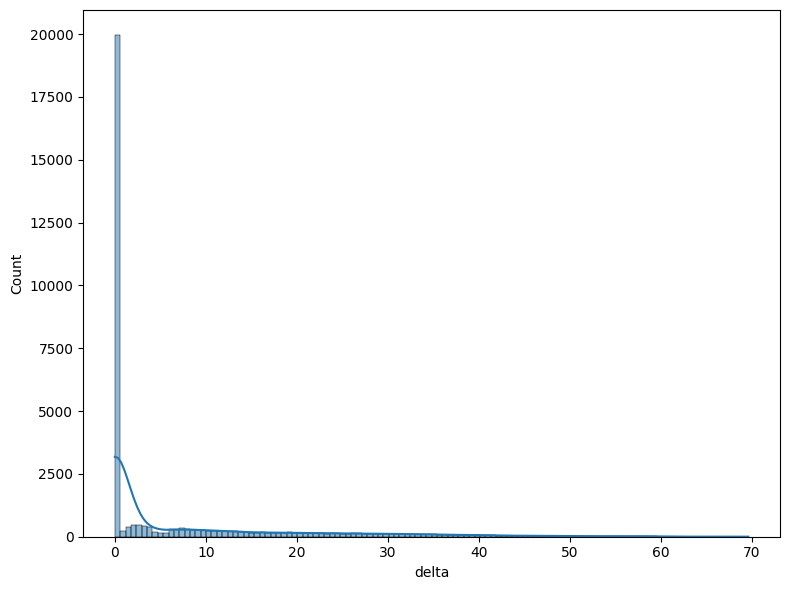

In [50]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.histplot(delta_df.delta, kde = True, ax = ax)

plt.tight_layout()
plt.show()

In [51]:
def temperature_trend(site_id: str, aggregation: Optional[Literal["sum", "mean"]] = None,
               cadence: str = None) -> pd.DataFrame:

    query = """
                    SELECT
                        date::DATE as date,
                        avg_temp_c,
                    FROM
                        Operations
                    WHERE
                        site_id == ?
                    ORDER BY
                        date::DATE ASC;
    """
    
    df = con.execute(query, [site_id]).df()

    if aggregation:
        df.set_index("date", inplace = True)
        if aggregation == "sum":
           df = df.resample(cadence)["avg_temp_c"].sum().to_frame()
        else:
            df = df.resample(cadence)["avg_temp_c"].mean().to_frame()

        df.reset_index(inplace = True)

    return df

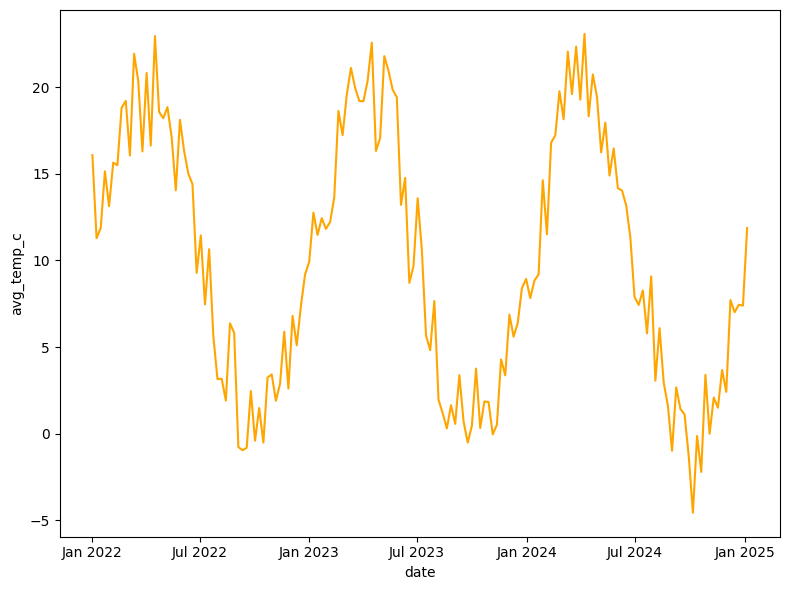

In [52]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(
    data = temperature_trend("SITE_006", aggregation = "mean", cadence = "1W"),
    x = "date", y = "avg_temp_c", color = "orange", ax = ax
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [53]:
def rain_trend(site_id: str, aggregation: Optional[Literal["sum", "mean"]] = None,
               cadence: str = None) -> pd.DataFrame:

    query = """
                    SELECT
                        date::DATE as date,
                        rain_mm,
                    FROM
                        Operations
                    WHERE
                        site_id == ?
                    ORDER BY
                        date::DATE ASC;
    """
    
    df = con.execute(query, [site_id]).df()

    if aggregation:
        df.set_index("date", inplace = True)
        if aggregation == "sum":
           df = df.resample(cadence)["rain_mm"].sum().to_frame()
        else:
            df = df.resample(cadence)["rain_mm"].mean().to_frame()

        df.reset_index(inplace = True)

    return df

In [151]:
def weather_view(data: pd.DataFrame,
                  weather_type: Literal["rain_mm", "avg_temp_c"] = "avg_temp_c") -> None:

    fig, ax = plt.subplots(figsize = (8, 6))

    sns.lineplot(data = data, x = "date", y = weather_type,
                 color = "orange", ax = ax)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.tight_layout()
    plt.show()

In [155]:
def cement_trend(site_id: str, cement_type: str, aggregation: bool = False,
          cadence: Optional[str] = None) -> pd.DataFrame:

    query = """

                SELECT
                    date::DATE as date,
                    planned_pour_tonnes,
                    consumed_tonnes
                FROM
                    Operations
                WHERE
                    site_id == ? AND cement_type == ?
                ORDER BY
                    date::DATE ASC;
    """

    df = con.execute(query, [site_id, cement_type]).df()

    df.set_index("date", inplace = True)

    date_range = pd.date_range(
        start = OPERATION_START_DATE,
        end = OPERATION_END_DATE,
        freq = "1d"
    ).rename("date")

    df = pd.merge(
        pd.DataFrame(index = date_range),
        df,
        how = "left",
        left_index = True,
        right_index = True
    )

    df.fillna(0, inplace = True)

    if aggregation:
        df = pd.merge(
            df.resample(cadence)["planned_pour_tonnes"].sum().to_frame(),
            df.resample(cadence)["consumed_tonnes"].sum().to_frame(),
            how = "inner",
            left_index = True,
            right_index = True
        )

    return df

In [156]:
pour_trend = cement_trend("SITE_015", "CEM_II", aggregation = True, cadence = "W")

In [57]:
pour_trend.head(10)

,planned_pour_tonnes,consumed_tonnes
date,,
2022-01-02,0.00,0.00
2022-01-09,26.83,26.83
2022-01-16,60.53,60.53
2022-01-23,27.07,27.07
2022-01-30,20.54,20.54
2022-02-06,38.81,38.81
2022-02-13,46.96,46.96
2022-02-20,11.66,11.66
2022-02-27,24.58,24.58


In [58]:
pour_trend.corr()

,planned_pour_tonnes,consumed_tonnes
planned_pour_tonnes,1.000000,0.994161
consumed_tonnes,0.994161,1.000000


In [59]:
def measure_correlation(trend_data: pd.DataFrame) -> pd.DataFrame:
    data = {}
    for col in trend_data.columns.tolist():
        correlation = []
        for i in range(55):
            df = pd.merge(
                trend_data[col].rename("present"),
                trend_data[col].shift(i).dropna().rename("past"),
                how = "inner",
                left_index = True,
                right_index = True
            )

            correlation.append(df.present.corr(df.past).round(3))
        data[col] = correlation

    return pd.DataFrame(data = data)

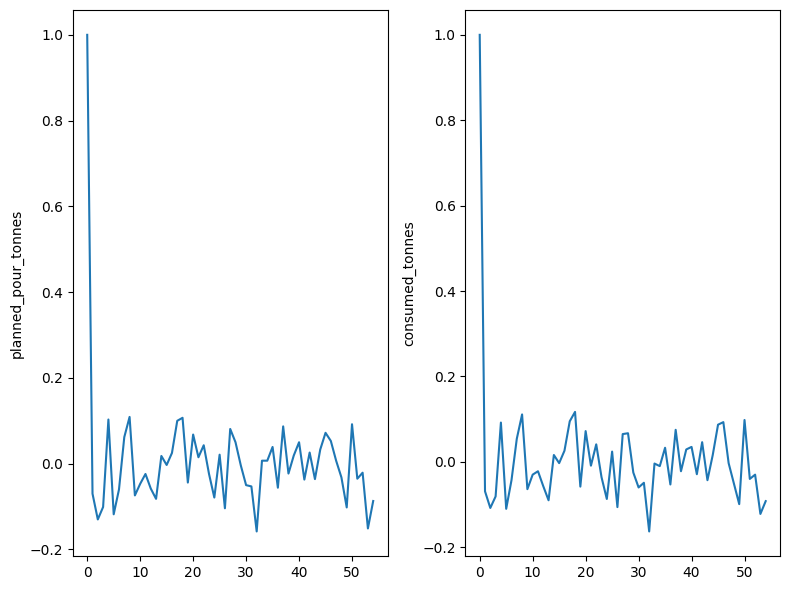

In [60]:
data = measure_correlation(pour_trend)

fig, ax = plt.subplots(1, 2, figsize = (8, 6))

sns.lineplot(data.planned_pour_tonnes, ax = ax[0])
sns.lineplot(data.consumed_tonnes, ax = ax[1])

plt.tight_layout()
plt.show()

In [71]:
def kpss_test(series: pd.Series) -> Tuple[float, float, str]:

    stat, p_value, _, _, = kpss(
        series, regression = "c"
    )

    decision = "non-stationary" if p_value < 0.05 else "stationary"

    return stat.round(3), p_value.round(3), decision

In [ ]:
def adf_test(series: pd.Series) -> Tuple[float, float, str]:
    result = adfuller(series)
    stat, p_value = result[0].round(3), result[1].round(3)
    decision = "stationary" if p_value < 0.05 else "non-stationary"

    return stat, p_value, decision

In [157]:
def stionarity_by_site(site_id: str, cadence: str = "W", kind: str = "kpss") -> pd.DataFrame:

    test_type = {
        "adf": adf_test,
        "kpss": kpss_test
    }

    result = {}
    cements =  ["CEM_I", "CEM_II", "CEM_III"]
    for column in ["planned_pour_tonnes", "consumed_tonnes"]:
        for cement in cements:
            data = cement_trend(site_id = site_id, cement_type = cement,
                         aggregation = True, cadence = cadence)

            series = data[column]
            test_func = test_type[kind]
            stat, p_value, decision = test_func(series)

            result[column] = result.get(column, []) + [decision]

    return pd.DataFrame(data = result, columns = data.columns.tolist(), index = cements)

In [158]:
for site in sites:
    result = stionarity_by_site(site_id = site, cadence = "1W", kind = "adf").values.ravel().tolist()
    if "non-stationary" in result:
        print(site)

In [120]:
stionarity_by_site(site_id = "SITE_006", kind = "kpss")

,planned_pour_tonnes,consumed_tonnes
CEM_I,stationary,stationary
CEM_II,stationary,non-stationary
CEM_III,stationary,stationary


In [121]:
stionarity_by_site(site_id = "SITE_017", kind = "kpss")

,planned_pour_tonnes,consumed_tonnes
CEM_I,non-stationary,non-stationary
CEM_II,stationary,stationary
CEM_III,stationary,stationary


In [122]:
stionarity_by_site(site_id = "SITE_025", kind = "kpss")

,planned_pour_tonnes,consumed_tonnes
CEM_I,stationary,stationary
CEM_II,non-stationary,non-stationary
CEM_III,stationary,stationary


In [123]:
stionarity_by_site(site_id = "SITE_028", kind = "kpss")

,planned_pour_tonnes,consumed_tonnes
CEM_I,non-stationary,stationary
CEM_II,stationary,stationary
CEM_III,stationary,stationary


In [125]:
def view_trend(data: pd.DataFrame) -> None:

    fig, ax = plt.subplots(figsize = (8, 6))

    sns.lineplot(data = data.reset_index(), x = "date", y = "planned_pour_tonnes",
                 color = "orange", ax = ax)
    sns.lineplot(data = data.reset_index(), x = "date", y = "consumed_tonnes",
                 color = "green", ax = ax)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.tight_layout()
    plt.show()

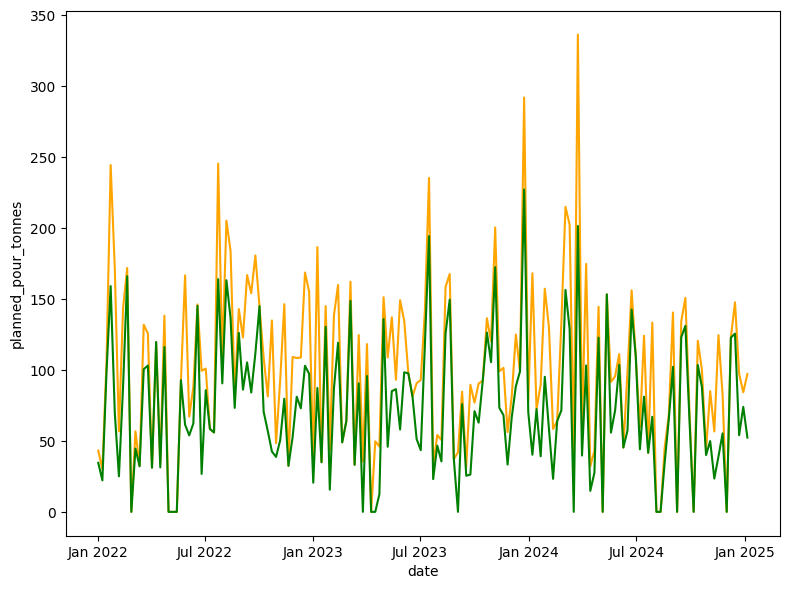

In [159]:
view_trend(
    data = cement_trend(
        site_id = "SITE_001", cement_type = "CEM_II",
        aggregation = True, cadence = "1W"
    )
)

In [160]:
cement_trend(site_id = "SITE_006", cement_type = "CEM_II", aggregation = True, cadence = "W")

,planned_pour_tonnes,consumed_tonnes
date,,
2022-01-02,0.00,0.00
2022-01-09,95.39,95.39
2022-01-16,72.85,31.16
2022-01-23,0.00,0.00
2022-01-30,145.08,73.41
...,...,...
2024-12-08,115.99,115.99
2024-12-15,110.75,58.95
2024-12-22,98.50,98.50


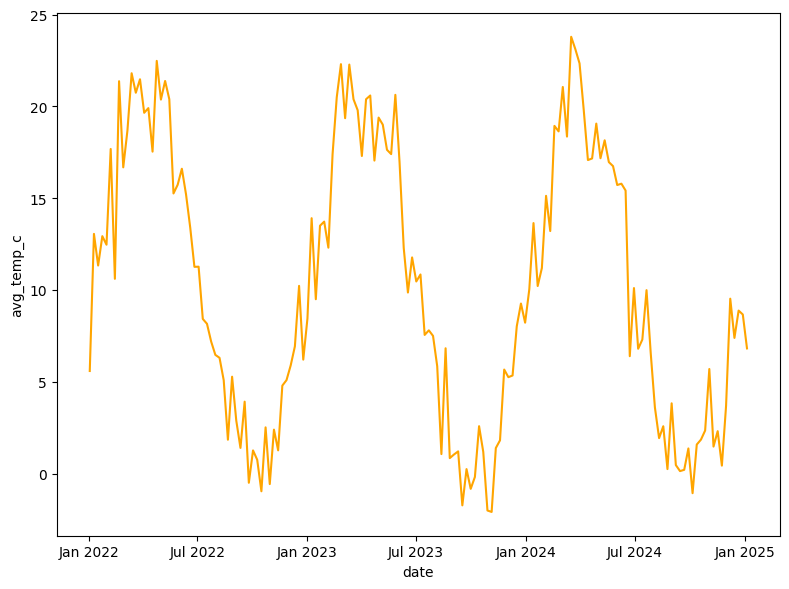

In [185]:
weather_view(temperature_trend("SITE_001", aggregation = "mean", cadence = "1W"),
             weather_type = "avg_temp_c")

In [145]:
site_temp = temperature_trend("SITE_006", aggregation = "mean", cadence = "1W")

In [146]:
site_temp

,date,avg_temp_c
0,2022-01-02,16.075000
1,2022-01-09,11.280000
2,2022-01-16,11.872857
3,2022-01-23,15.141429
4,2022-01-30,13.127143
...,...,...
153,2024-12-08,7.714286
154,2024-12-15,7.008571
155,2024-12-22,7.442857
156,2024-12-29,7.391429


In [237]:
temp_signal = temperature_trend(
    site_id = "SITE_001",
    aggregation = "mean",
    cadence = "1W"
)

In [169]:
# sample signal
n = 1000
t = np.arange(n)

signal = (
    3*np.sin(2*np.pi*t/7) +      # weekly seasonality
    1.5*np.sin(2*np.pi*t/30) +   # monthly seasonality
    np.random.normal(0, 1, n)
)

In [180]:
pd.Series(signal).rolling(7).mean().dropna()

6      1.024984
7      1.208132
8      1.275988
9      0.797890
10     0.646518
         ...   
995    0.800952
996    1.361682
997    1.446317
998    1.330972
999    0.956920
Length: 994, dtype: float64

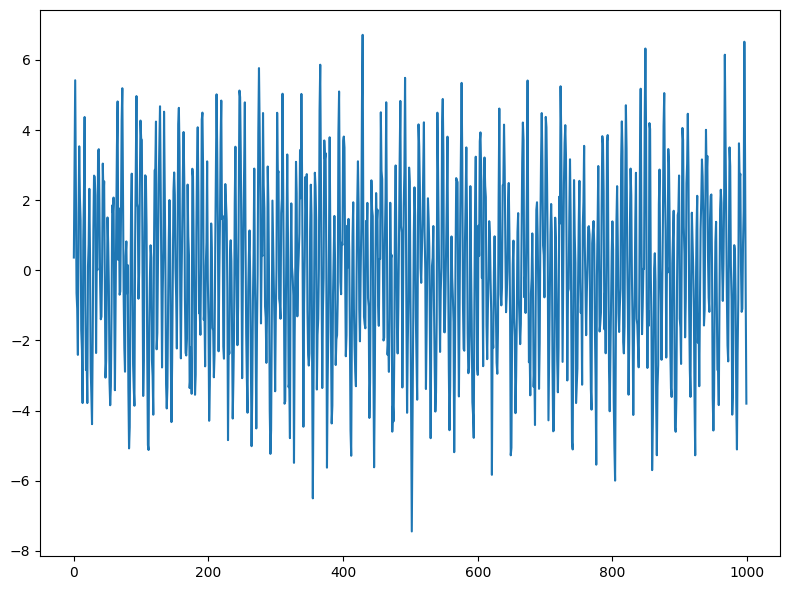

In [179]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(signal, ax = ax)

plt.tight_layout()
plt.show()

In [222]:
planned_cement_trend = cement_trend(
    site_id = "SITE_001",
    cement_type = "CEM_II",
    aggregation = True,
    cadence = "1w"
)

In [223]:
# FFT
n = planned_cement_trend.planned_pour_tonnes.values.size

yf = fft(planned_cement_trend.planned_pour_tonnes.values)

# frequencies
xf = fftfreq(n, d=1)

# positive frequencies only
mask = xf > 0

freqs = xf[mask]
power = np.abs(yf[mask])**2

In [224]:
periods = 1 / freqs

In [225]:
power.argmax()

np.int64(59)

In [226]:
periods[59]

np.float64(2.6333333333333337)

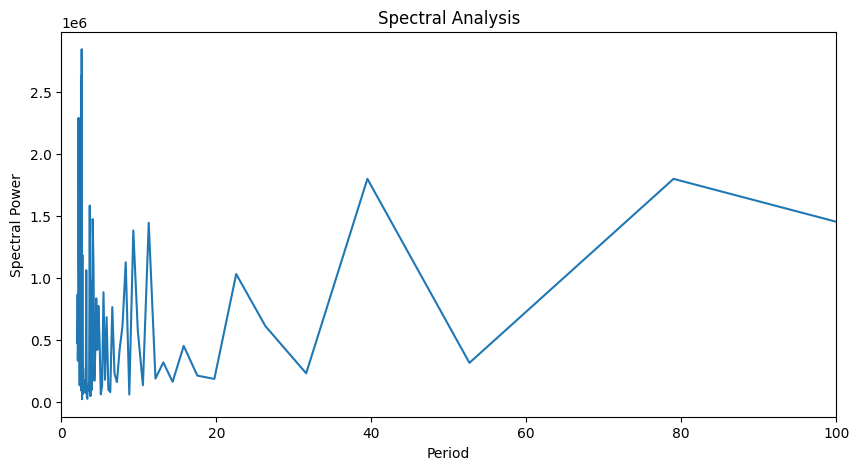

In [228]:
plt.figure(figsize=(10,5))

plt.plot(periods, power)

plt.xlim(0, 100)
plt.xlabel("Period")
plt.ylabel("Spectral Power")
plt.title("Spectral Analysis")

plt.show()

In [299]:
acf_values, confint = acf(
    planned_cement_trend.planned_pour_tonnes.values,
    nlags = 60,
    alpha = 0.05,
    fft = False
)

In [301]:
acf_values

array([ 1.        , -0.0357501 ,  0.11711614, -0.00254989,  0.02586366,
        0.14251312, -0.13136346,  0.00571788,  0.14484108,  0.04752139,
        0.02533334,  0.04522527, -0.08822269,  0.11551098, -0.16112955,
       -0.06389107,  0.04723068, -0.10127052,  0.09631223, -0.11475843,
       -0.01715004, -0.02256967, -0.03880147, -0.01418263, -0.06724164,
        0.04179498, -0.0275056 , -0.01497376, -0.11423502,  0.08849924,
       -0.12971533, -0.11060392, -0.03776444, -0.00379097,  0.03009824,
       -0.09797781, -0.01395547, -0.07307307,  0.01757249, -0.05927037,
       -0.04501188, -0.01725994, -0.00487604,  0.00628825,  0.0052122 ,
        0.07459199,  0.02445074,  0.03491027, -0.00346398, -0.00962974,
       -0.02487829, -0.00767447, -0.0704111 , -0.01768966,  0.0226555 ,
        0.03853665, -0.04088084, -0.08242561,  0.08282111,  0.0310919 ,
       -0.05490457])

In [307]:
xx_df = pd.DataFrame(
    data = {
        "lags": range(1, 61),
        "lower": confint[1:, 0],
        "acf": acf_values[1:],
        "upper": confint[1:, 1]
    }
)

In [ ]:
xx_df[]

,lags,lower,acf,upper
0,1,-0.191676,-0.035750,0.120176
1,2,-0.039009,0.117116,0.273242
2,3,-0.160797,-0.002550,0.155697
3,4,-0.132384,0.025864,0.184112
4,5,-0.015838,0.142513,0.300864
5,6,-0.292803,-0.131363,0.030076
6,7,-0.158299,0.005718,0.169735
7,8,-0.019181,0.144841,0.308863
8,9,-0.119582,0.047521,0.214624
9,10,-0.142098,0.025333,0.192765


In [302]:
significant_lags = []

for lag in range(1, 61):
    lower = confint[lag, 0]
    upper = confint[lag, 1]

    if acf_values[lag] < lower or acf_values[lag] > upper:
        significant_lags.append(lag)

print("Significant lags:")
print(significant_lags)

Significant lags:
[]


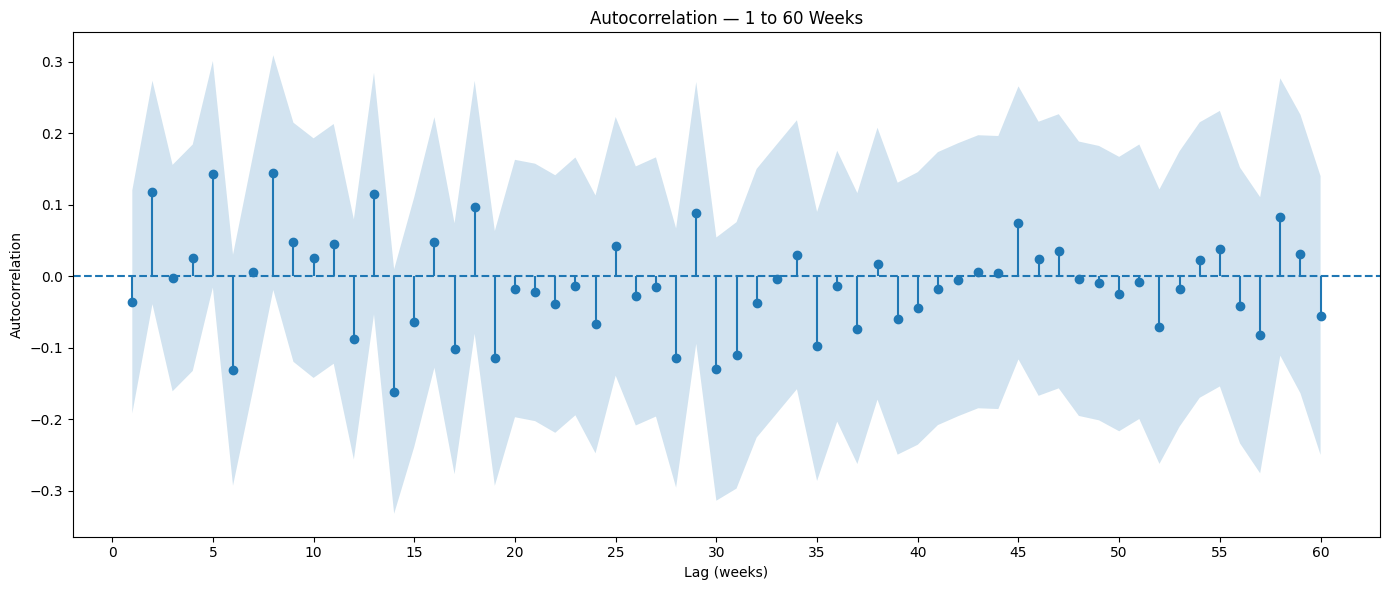

In [303]:
fig, ax = plt.subplots(figsize=(14, 6))

lags_array = np.arange(1, 60 + 1)

acf_plot = acf_values[1:]

# Confidence interval around zero
lower = confint[1:, 0]
upper = confint[1:, 1]

ax.stem(
    lags_array,
    acf_plot,
    basefmt=" "
)

# Confidence interval
ax.fill_between(
    lags_array,
    lower,
    upper,
    alpha=0.2
)

# Highlight significant lags
significant = (
    (acf_plot < lower) |
    (acf_plot > upper)
)

ax.scatter(
    lags_array[significant],
    acf_plot[significant],
    s=60,
    zorder=3
)

ax.axhline(0, linestyle="--")

ax.set_xlabel("Lag (weeks)")
ax.set_ylabel("Autocorrelation")

ax.set_title(
    "Autocorrelation — 1 to 60 Weeks"
)

ax.set_xticks(np.arange(0, 61, 5))

plt.tight_layout()
plt.show()

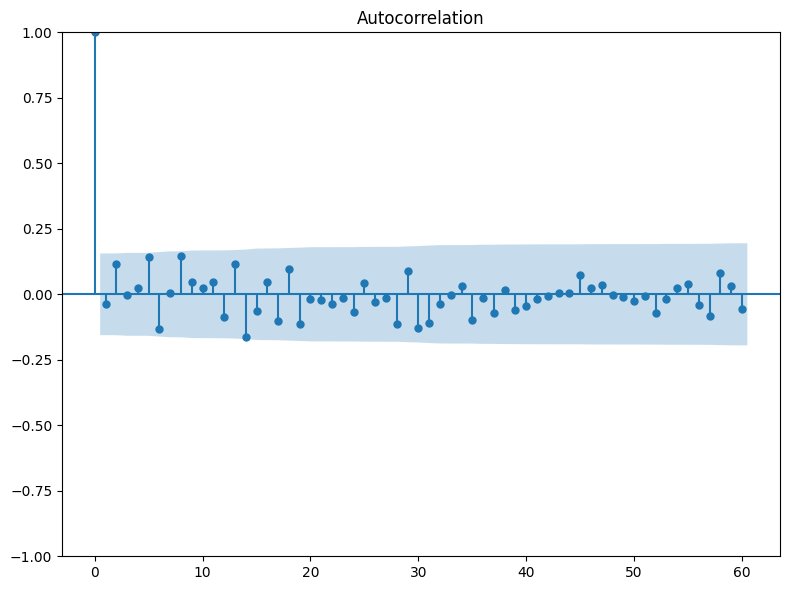

In [269]:
fig, ax = plt.subplots(figsize = (8, 6))

plot_acf(planned_cement_trend.planned_pour_tonnes.values, lags = 60, ax = ax)

plt.tight_layout()
plt.show()

In [297]:
np.abs(acf_values[1:]).max()

np.float64(0.16112954585062597)

In [277]:
np.abs(acf_values[1:]).argmax()

np.int64(13)

In [309]:
present = planned_cement_trend["2022-04-03":]["planned_pour_tonnes"].values

In [310]:
lag = planned_cement_trend.planned_pour_tonnes.shift(13).dropna().values

In [311]:
slope, intercept, r_value, p_value, std_err = linregress(present, lag)

In [312]:
slope, p_value

(np.float64(0.12940441455503884), np.float64(0.13574366389957623))

In [315]:
r, p_value = pearsonr(present, lag)

In [ ]:
def temp_lag_correlation(site_id: str, aggregation: bool = True,
                         cadence: Optional[str] = "W", lags: int = 60) -> pd.DataFrame:

    data = temperature_trend(site_id = site_id, aggregation = aggregation,
                             cadence = cadence)

    correlation_data = []
    for i in range(1, 2):
        df = pd.concat(
            [
                data.avg_temp_c[i:].rename("present").reset_index(drop = True),
                data.avg_temp_c.shift(i).dropna().rename("lag").reset_index(drop = True)
            ],
            axis = 1,
            ignore_index = False
        )

        r, p_value = pearsonr(df.present.values, df.lag.values)

        correlation_data.append(
            [i, r.round(3), p_value.round(3)]
        )

    corr_df = 

In [343]:
temp_lag_correlation("SITE_001")

0.922 0.0


In [333]:
dd = temperature_trend(
    site_id = "SITE_001",
    aggregation = True,
    cadence = "W"
)

pd.concat(
    [dd.avg_temp_c[10:].rename("present"), dd.avg_temp_c.shift(10).dropna().rename("lag")],
    axis = 1, ignore_index = False
)

,present,lag
10,21.810000,5.590000
11,20.748571,13.060000
12,21.482857,11.337143
13,19.655714,12.935714
14,19.911429,12.470000
...,...,...
153,9.530000,1.371429
154,7.392857,-1.065714
155,8.881429,1.584286
156,8.668571,1.851429


In [325]:
dd.head(20)

,date,avg_temp_c
0,2022-01-02,5.590000
1,2022-01-09,13.060000
2,2022-01-16,11.337143
3,2022-01-23,12.935714
4,2022-01-30,12.470000
5,2022-02-06,17.685714
6,2022-02-13,10.611429
7,2022-02-20,21.377143
8,2022-02-27,16.684286
9,2022-03-06,18.692857


In [330]:
dd.avg_temp_c.shift(10).head(20)

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6           NaN
7           NaN
8           NaN
9           NaN
10     5.590000
11    13.060000
12    11.337143
13    12.935714
14    12.470000
15    17.685714
16    10.611429
17    21.377143
18    16.684286
19    18.692857
Name: avg_temp_c, dtype: float64

In [327]:
dd.shift(10).head(20)

,date,avg_temp_c
0,NaT,NaN
1,NaT,NaN
2,NaT,NaN
3,NaT,NaN
4,NaT,NaN
5,NaT,NaN
6,NaT,NaN
7,NaT,NaN
8,NaT,NaN
9,NaT,NaN


In [321]:
dd.shift(1).dropna()

,date,avg_temp_c
1,2022-01-02,5.590000
2,2022-01-09,13.060000
3,2022-01-16,11.337143
4,2022-01-23,12.935714
5,2022-01-30,12.470000
...,...,...
153,2024-12-01,3.690000
154,2024-12-08,9.530000
155,2024-12-15,7.392857
156,2024-12-22,8.881429


In [316]:
r, p_value

(np.float64(0.12448475335490992), np.float64(0.13574366389957723))

In [271]:
confint[2, 0], confint[2, 1]

(np.float64(-0.03900937616235772), np.float64(0.2732416639428885))

In [231]:
acf_values

array([ 1.        , -0.0357501 ,  0.11711614, -0.00254989,  0.02586366,
        0.14251312, -0.13136346,  0.00571788,  0.14484108,  0.04752139,
        0.02533334,  0.04522527, -0.08822269,  0.11551098, -0.16112955,
       -0.06389107,  0.04723068, -0.10127052,  0.09631223, -0.11475843,
       -0.01715004, -0.02256967, -0.03880147, -0.01418263, -0.06724164,
        0.04179498, -0.0275056 , -0.01497376, -0.11423502,  0.08849924,
       -0.12971533, -0.11060392, -0.03776444, -0.00379097,  0.03009824,
       -0.09797781, -0.01395547, -0.07307307,  0.01757249, -0.05927037,
       -0.04501188, -0.01725994, -0.00487604,  0.00628825,  0.0052122 ,
        0.07459199,  0.02445074,  0.03491027, -0.00346398, -0.00962974,
       -0.02487829, -0.00767447, -0.0704111 , -0.01768966,  0.0226555 ,
        0.03853665, -0.04088084, -0.08242561,  0.08282111,  0.0310919 ,
       -0.05490457])

In [204]:
pour_trend.planned_pour_tonnes.shift(52).dropna().rename("past")

date
2023-01-01     0.00
2023-01-08    26.83
2023-01-15    60.53
2023-01-22    27.07
2023-01-29    20.54
              ...  
2024-12-08    15.99
2024-12-15    22.75
2024-12-22    49.96
2024-12-29    25.38
2025-01-05    38.75
Freq: W-SUN, Name: past, Length: 106, dtype: float64

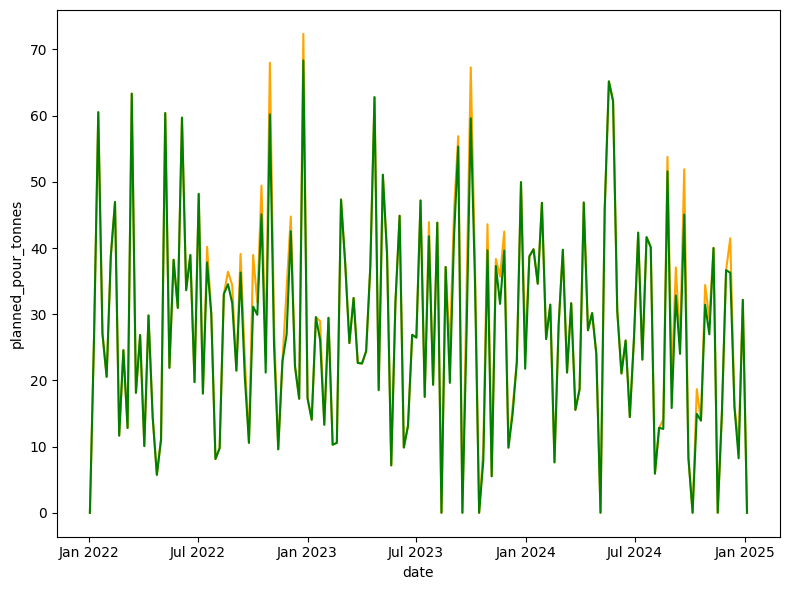

In [178]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(data = pour_trend.reset_index(), x = "date", y = "planned_pour_tonnes", color = "orange", ax = ax)
sns.lineplot(data = pour_trend.reset_index(), x = "date", y = "consumed_tonnes", color = "green", ax = ax)

ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [256]:
con.execute(" SELECT COUNT(1) FROM Operations WHERE consumed_tonnes > planned_pour_tonnes; ").fetchone()

(0,)